## Trainina logistic regression

In [6]:
# run in slurm
!sbatch run_bash/run_regression_training_noexpr.sh


Submitted batch job 19507206


In [71]:
# run in slurm
!sbatch run_bash/run_regression_training_noexpr_delta.sh


Submitted batch job 19507445


In [62]:
# run in slurm
!sbatch run_bash/run_regression_training.sh


Submitted batch job 19492642


In [10]:
# run training with summary data
!sbatch run_bash/run_regression_training_summary.sh


Submitted batch job 19429112


In [73]:
!squeue -u $USER  # check your jobs in the queue

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)
          19507269 jupyterhu   vscode     zhow  R    3:23:06      1 ouga17
          19507445  standard training     zhow  R       0:16      1 ouga20


In [69]:
!scancel 19507440

In [4]:
df_train = pd.read_parquet("results_logistic/df_train.parquet")

In [6]:
df_train.shape

(131634, 723)

In [23]:
from sklearn.feature_selection import VarianceThreshold



X = df_train_sample.drop(
    columns=["variant_id", "rare"]
)

X = X.fillna(0)


In [24]:
X.shape

(26327, 721)

In [25]:
from sklearn.model_selection import train_test_split

y = df_train_sample["rare"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(21061, 721)
(5266, 721)


In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        solver="saga",
        l1_ratio=1.0,
        class_weight="balanced",
        max_iter=5000,
        random_state=42,
    )
)

param_grid = {"logisticregression__C": [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

# Use full dataset with 10-fold CV for grid search
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

gs = GridSearchCV(
    model,
    param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1       # shows progress
)

# Use full X and y instead of just X_train
import time

start = time.time()
gs.fit(X, y)
elapsed = time.time() - start

print(f"Best C: {gs.best_params_}")
print(f"Best CV AUC: {gs.best_score_:.3f}")
print(f"Training time: {elapsed/60:.1f} min")

print(f"Best C: {gs.best_params_}")
print(f"Best CV AUC: {gs.best_score_:.3f}")

# Show all C values and their scores
cv_results = pd.DataFrame(gs.cv_results_)
print(cv_results[["param_logisticregression__C", "mean_test_score", "std_test_score"]]
      .sort_values("mean_test_score", ascending=False))

import joblib
# Save the best model
joblib.dump(gs.best_estimator_, "results_logistic/best_model.pkl")
# Save CV results
pd.DataFrame(gs.cv_results_).to_csv("results_logistic/cv_results.csv", index=False)

print("Model and CV results saved!")

Fitting 10 folds for each of 5 candidates, totalling 50 fits


KeyboardInterrupt: 

In [27]:
from sklearn.model_selection import train_test_split

# Sample 1% stratified by class
X_sample, _, y_sample, _ = train_test_split(
    X, y,
    train_size=0.01,
    stratify=y,
    random_state=42
)

print(f"Sample shape: {X_sample.shape}")
print(f"Class balance:\n{pd.Series(y_sample).value_counts(normalize=True).round(3)}")

# Train on sample
start = time.time()
gs.fit(X_sample, y_sample)
elapsed = time.time() - start

print(f"Best C: {gs.best_params_}")
print(f"Best CV AUC: {gs.best_score_:.3f}")
print(f"Training time: {elapsed/60:.1f} min")

# Extrapolate full training time
print(f"Estimated full training time: {elapsed/60 * 100:.1f} min")

Sample shape: (263, 721)
Class balance:
rare
1    0.757
0    0.243
Name: proportion, dtype: float64
Fitting 10 folds for each of 5 candidates, totalling 50 fits
Best C: {'logisticregression__C': 10}
Best CV AUC: 0.562
Training time: 0.4 min
Estimated full training time: 44.8 min


## Model evaluation

In [1]:
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score, roc_curve
from sklearn.model_selection import cross_val_predict, StratifiedKFold
import matplotlib.pyplot as plt
from tqdm import tqdm
import matplotlib.ticker as ticker
from sklearn.model_selection import train_test_split

In [2]:

def evaluate_model(X, best_model):
    y = X["rare"].values
    X = X.drop(columns=["rare", "variant_id"])
    # get the feature names the scaler was fitted on
    trained_features = best_model.named_steps['standardscaler'].feature_names_in_

    X = df_train.drop(columns=["variant_id", "rare"], errors="ignore")
    X = X.reindex(columns=trained_features, fill_value=0)  # align + fill missing cols with 0
    X = X.fillna(0)
    X = X.values
    pred_prob = best_model.predict_proba(X)[:, 1]

    # Metrics
    auc = roc_auc_score(y, pred_prob)
    auprc = average_precision_score(y, pred_prob)
    print(f"AUC-ROC: {auc:.3f}")
    print(f"AUPRC: {auprc:.3f}")
    print(f"Random baseline AUPRC: {y.mean():.3f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # ROC curve
    fpr, tpr, _ = roc_curve(y, pred_prob)
    axes[0].plot(fpr, tpr, label=f"AUC-ROC = {auc:.3f}")
    axes[0].plot([0, 1], [0, 1], "r--", label="Random baseline = 0.5")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title("ROC Curve")
    axes[0].legend()

    # Precision-Recall curve
    precision, recall, _ = precision_recall_curve(y, pred_prob)
    axes[1].plot(recall, precision, label=f"AUPRC = {auprc:.3f}")
    axes[1].axhline(y=y.mean(), color="red", linestyle="--", label=f"Random baseline = {y.mean():.3f}")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title("Precision-Recall Curve")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("results_logistic/evaluation_curves_track_strand_expr_specie.png", dpi=150)
    plt.show()
    

def precision_at_top_k(X, best_model, start_point=1000, n_bootstrap=1000):
    y = X["rare"].values
    X = X.drop(columns=["rare", "variant_id"])
    # get the feature names the scaler was fitted on
    trained_features = best_model.named_steps['standardscaler'].feature_names_in_

    X = X.reindex(columns=trained_features, fill_value=0)  # align + fill missing cols with 0
    X = X.fillna(0)
    X = X.values
    pred_prob = best_model.predict_proba(X)[:, 1]

    n_variants = len(pred_prob)
    sorted_idx = np.argsort(pred_prob)[::-1]

    # Log-spaced thresholds starting at ~1000 variants
    pct_min = start_point / n_variants
    thresholds_pct = np.logspace(np.log10(pct_min), 2, 200) / 100

    # --- Main run ---
    results = []
    ks = []
    seen_k = set()
    for pct in thresholds_pct:
        k = max(start_point, int(n_variants * pct))
        k = min(k, n_variants)
        if k in seen_k:
            continue
        seen_k.add(k)
        ks.append((pct, k))
        top_k_idx = sorted_idx[:k]
        results.append({
            "top_%": pct * 100,
            "n_variants": k,
            "precision": y[top_k_idx].mean(),
            "baseline_precision": y.mean()
        })

    df_results = pd.DataFrame(results)

    # --- Bootstrap CI ---
    rng = np.random.default_rng(42)
    boot_precisions = {k: [] for _, k in ks}
    for _ in tqdm(range(n_bootstrap), desc="Bootstrapping"):
        boot_idx = rng.integers(0, n_variants, size=n_variants)
        boot_y = y[boot_idx]
        boot_prob = pred_prob[boot_idx]
        boot_sorted = np.argsort(boot_prob)[::-1]
        for _, k in ks:
            boot_precisions[k].append(boot_y[boot_sorted[:k]].mean())

    df_results["precision_low"]  = [np.percentile(boot_precisions[k], 2.5)  for _, k in ks]
    df_results["precision_high"] = [np.percentile(boot_precisions[k], 97.5) for _, k in ks]

    # print(df_results.to_string(index=False))

    baseline = y.mean()

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.fill_between(df_results["n_variants"],
                    df_results["precision_low"],
                    df_results["precision_high"],
                    alpha=0.2, color="steelblue", label="95% CI (bootstrap)")
    ax.plot(df_results["n_variants"], df_results["precision"], "o-",
            color="steelblue", markersize=3, linewidth=1.5, label="Model precision")
    ax.axhline(baseline, color="red", linestyle="--", label=f"Baseline = {baseline:.3f}")

    for _, row in df_results.iloc[::8].iterrows():
        ax.annotate(f"n={int(row['n_variants'])}",
                    xy=(row["n_variants"], row["precision"]),
                    xytext=(0, 8), textcoords="offset points",
                    fontsize=7, ha="center", color="steelblue")

    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:g}"))
    ax.xaxis.set_minor_formatter(ticker.NullFormatter())
    ax.set_xlabel(f"Top N variants by score (total = {n_variants:,})")
    ax.set_ylabel("Precision (fraction truly rare)")
    ax.set_title("Precision at Top K (95% bootstrap CI)")
    ax.legend()
    plt.tight_layout()
    plt.savefig("results_logistic/precision_at_top_k.png", dpi=150)
    plt.show()
    

def precision_at_top_k_per_track(X, best_model, n_bootstrap=100, top_n_tracks=10):
    """
    Plots precision-at-top-K for:
    - Logistic regression model
    - Max alt score across all tracks
    - Top N most predictive individual tracks
    """
    y = X["rare"].values
    trained_features = best_model.named_steps['standardscaler'].feature_names_in_

    X_feat = X.drop(columns=["variant_id", "rare"], errors="ignore")
    X_feat = X_feat.reindex(columns=trained_features, fill_value=0).fillna(0)

    pred_prob = best_model.predict_proba(X_feat.values)[:, 1]
    
    
    n_variants = len(pred_prob)

    # ── thresholds ────────────────────────────────────────────────────────────
    pct_min = 100 / n_variants
    thresholds_pct = np.logspace(np.log10(pct_min), 2, 200) / 100
    ks = []
    seen_k = set()
    for pct in thresholds_pct:
        k = min(max(100, int(n_variants * pct)), n_variants)
        if k not in seen_k:
            seen_k.add(k)
            ks.append((pct, k))

    def curve_from_scores(scores):
        sorted_idx = np.argsort(scores)[::-1]
        return pd.DataFrame([
            {"top_%": pct * 100, "n_variants": k, "precision": y[sorted_idx[:k]].mean()}
            for pct, k in ks
        ])

    # ── model curve + bootstrap CI ────────────────────────────────────────────
    df_model = curve_from_scores(pred_prob)
    rng = np.random.default_rng(42)
    boot_precisions = {k: [] for _, k in ks}
    for _ in tqdm(range(n_bootstrap), desc="Bootstrapping model"):
        boot_idx = rng.integers(0, n_variants, size=n_variants)
        boot_sorted = np.argsort(pred_prob[boot_idx])[::-1]
        for _, k in ks:
            boot_precisions[k].append(y[boot_idx][boot_sorted[:k]].mean())
    df_model["precision_low"]  = [np.percentile(boot_precisions[k], 2.5)  for _, k in ks]
    df_model["precision_high"] = [np.percentile(boot_precisions[k], 97.5) for _, k in ks]

    # ── max alt score curve ───────────────────────────────────────────────────
    max_alt_score = X_feat.abs().max(axis=1).values
    df_max_alt = curve_from_scores(max_alt_score)

    # ── per-track curves: rank each track by AUC at top-10% ──────────────────
    k_screen = min(max(1000, int(n_variants * 0.10)), n_variants)
    track_aucs = {}
    for col in tqdm(X_feat.columns, desc="Screening tracks"):
        scores = X_feat[col].values
        sorted_idx = np.argsort(scores)[::-1]
        track_aucs[col] = y[sorted_idx[:k_screen]].mean()

    top_tracks = sorted(track_aucs, key=track_aucs.get, reverse=True)[:top_n_tracks]
    #print("Top tracks by precision at top 10%:")
    #for t in top_tracks:
        # print(f"  {t}: {track_aucs[t]:.3f}")

    track_curves = {col: curve_from_scores(X_feat[col].values) for col in top_tracks}

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(11, 6))
    baseline = y.mean()

    # per-track curves (light, in background)
    cmap = plt.cm.get_cmap("tab10", top_n_tracks)
    for i, col in enumerate(top_tracks):
        ax.plot(track_curves[col]["top_%"], track_curves[col]["precision"],
                linewidth=1, alpha=0.6, color=cmap(i),
                label=f"{col} ({track_aucs[col]:.3f})")

    # max alt
    ax.plot(df_max_alt["top_%"], df_max_alt["precision"], "k--",
            linewidth=1.5, label="Max alt score (all tracks)")

    # model (on top)
    ax.fill_between(df_model["top_%"], df_model["precision_low"], df_model["precision_high"],
                    alpha=0.2, color="steelblue")
    ax.plot(df_model["top_%"], df_model["precision"], "o-",
            color="steelblue", markersize=3, linewidth=2, label="Logistic regression")

    ax.axhline(baseline, color="red", linestyle="--", linewidth=1, label=f"Baseline = {baseline:.3f}")

    ax.set_xscale("log")
    ax.set_xlabel("Top X% of variants by score")
    ax.set_ylabel("Precision (fraction truly rare)")
    ax.set_title(f"Precision at Top K%: Model vs Max Alt vs Top {top_n_tracks} Individual Tracks")
    ax.legend(fontsize=7, loc="lower left", ncol=2)
    plt.tight_layout()
    plt.savefig("results_logistic/precision_at_top_k_per_track.png", dpi=150)
    plt.show()
    
    
def precision_at_top_k_per_track_smooth(X, best_model, top_n_tracks=10, starting_point=1000, smooth_window=5, label_spacing=0.3, show_max_alt=True):
    y = X["rare"].values
    trained_features = best_model.named_steps['standardscaler'].feature_names_in_

    X_feat = X.drop(columns=["variant_id", "rare"], errors="ignore")
    X_feat = X_feat.reindex(columns=trained_features, fill_value=0).fillna(0)

    pred_prob = best_model.predict_proba(X_feat.values)[:, 1]
    n_variants = len(pred_prob)

    # ── thresholds ────────────────────────────────────────────────────────────
    pct_min = 100 / n_variants
    thresholds_pct = np.logspace(np.log10(pct_min), 2, 2000) / 100
    ks = []
    seen_k = set()
    for pct in thresholds_pct:
        k = min(max(starting_point, int(n_variants * pct)), n_variants)
        if k not in seen_k:
            seen_k.add(k)
            ks.append((pct, k))

    def curve_from_scores(scores):
        sorted_idx = np.argsort(scores)[::-1]
        df = pd.DataFrame([
            {"top_%": pct * 100, "n_variants": k, "precision": y[sorted_idx[:k]].mean()}
            for pct, k in ks
        ])
        df["precision_smooth"] = df["precision"].rolling(window=smooth_window, center=True, min_periods=1).mean()
        return df

    def annotate_n(ax, df, color):
        last_x = -np.inf
        for _, row in df.iterrows():
            x = row["n_variants"]
            if x > 0 and np.log10(x) - np.log10(last_x + 1e-10) > label_spacing:
                ax.annotate(f"n={int(x):,}",
                            xy=(x, row["precision_smooth"]),
                            xytext=(0, 8), textcoords="offset points",
                            fontsize=7, ha="center", color=color)
                last_x = x

    df_model = curve_from_scores(pred_prob)

    # ── per-track curves ──────────────────────────────────────────────────────
    k_screen = min(max(1000, int(n_variants * 0.10)), n_variants)
    track_aucs = {}
    for col in tqdm(X_feat.columns, desc="Screening tracks"):
        scores = X_feat[col].values
        sorted_idx = np.argsort(scores)[::-1]
        track_aucs[col] = y[sorted_idx[:k_screen]].mean()

    top_tracks = sorted(track_aucs, key=track_aucs.get, reverse=True)[:top_n_tracks]
    #print("Top tracks by precision at top 10%:")
    #for t in top_tracks:
    #    print(f"  {t}: {track_aucs[t]:.3f}")
    track_curves = {col: curve_from_scores(X_feat[col].values) for col in top_tracks}

    # ── max fold change (alt - ref): only if requested ────────────────────────
    if show_max_alt:
        alt_cols = [c for c in X_feat.columns if c.endswith("_alt")]
        ref_cols  = [c for c in X_feat.columns if c.endswith("_ref")]
        alt_base  = {c.rsplit("_alt", 1)[0]: c for c in alt_cols}
        ref_base  = {c.rsplit("_ref", 1)[0]: c for c in ref_cols}
        common    = set(alt_base.keys()) & set(ref_base.keys())
        fc_matrix = pd.DataFrame({
            base: X_feat[alt_base[base]].values - X_feat[ref_base[base]].values
            for base in common
        })
        max_fc_score = fc_matrix.abs().max(axis=1).values
        df_max_alt = curve_from_scores(max_fc_score)

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(11, 6))
    baseline = y.mean()
    cmap = plt.cm.get_cmap("tab10", top_n_tracks)

    # per-track curves (background)
    for i, col in enumerate(top_tracks):
        ax.plot(track_curves[col]["n_variants"], track_curves[col]["precision_smooth"],
                linewidth=1, alpha=0.6, color=cmap(i),
                label=f"{col} ({track_aucs[col]:.3f})")

    if show_max_alt:
        ax.plot(df_max_alt["n_variants"], df_max_alt["precision_smooth"], "k--",
                linewidth=1.5, label="Max |fold change| (alt - ref)")
        annotate_n(ax, df_max_alt, "black")

    # model (on top)
    ax.plot(df_model["n_variants"], df_model["precision_smooth"],
            color="steelblue", markersize=1, linewidth=2, label="Logistic regression")
    annotate_n(ax, df_model, "steelblue")

    ax.axhline(baseline, color="red", linestyle="--", linewidth=1, label=f"Baseline = {baseline:.3f}")

    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:g}"))
    ax.xaxis.set_minor_formatter(ticker.NullFormatter())
    ax.set_xlabel(f"Top N variants by score (total = {n_variants:,})")
    ax.set_ylabel("Precision")
    ax.set_title(f"Precision at Top K: Model vs Max Absolute Foldchange vs Top {top_n_tracks} Individual Tracks")
    ax.legend(fontsize=7, loc="lower left", ncol=2)
    plt.tight_layout()
    plt.savefig("results_logistic/precision_at_top_k_per_track_smooth.png", dpi=150)
    plt.show()

In [ ]:
# use AF < 0.01 as rare variant definition as some paper suggested: https://www.nature.com/articles/ng.1074, https://www.nature.com/articles/s41586-021-03855-y

best_model = joblib.load("models/VS_per_track_delta_with-/best_model_VS_per_track_delta_with-.pkl")
df_test = pd.read_parquet("models/VS_per_track_delta_with-/df_test_VS_per_track_delta_with-.parquet")


/opt/modules/i12g/anaconda/envs/IDPproject_indel_26/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
Bootstrapping: 100%|██████████| 1000/1000 [00:01<00:00, 514.09it/s]


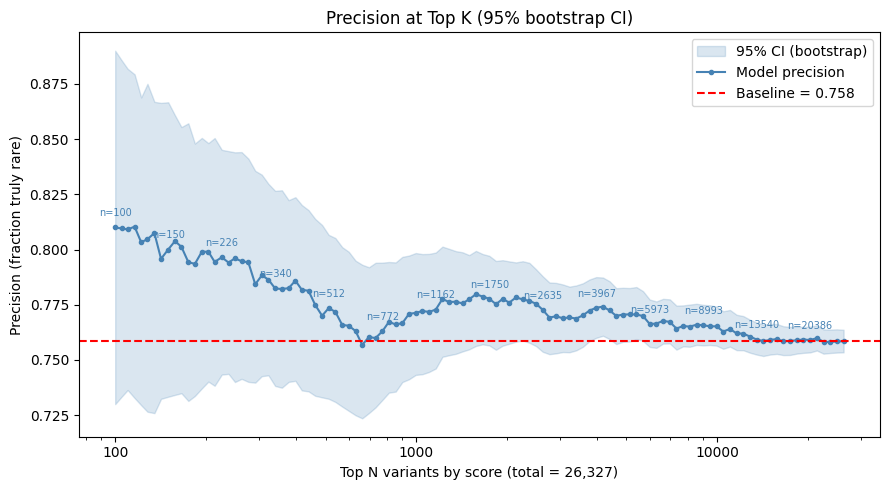

In [6]:

precision_at_top_k(df_test, best_model, start_point=100,)

/opt/modules/i12g/anaconda/envs/IDPproject_indel_26/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
Screening tracks: 100%|██████████| 372/372 [00:00<00:00, 1650.20it/s]
/scratch/tmp/zhow/ipykernel_766787/2200591822.py:202: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", top_n_tracks)


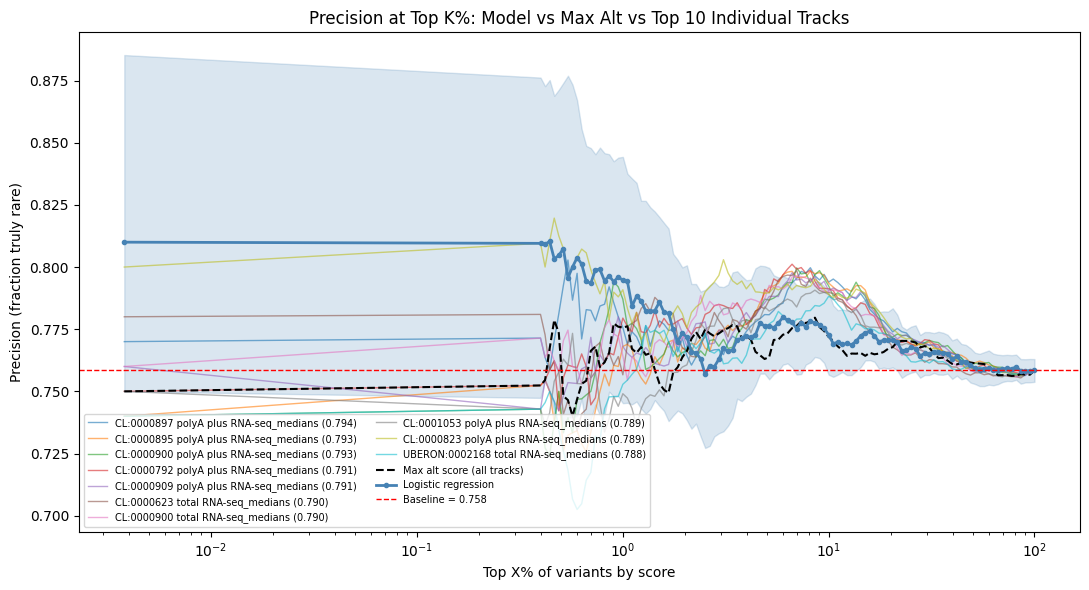

In [7]:
precision_at_top_k_per_track(df_test, best_model)

In [4]:
# use AF < 0.01 as rare variant definition as some paper suggested: https://www.nature.com/articles/ng.1074, https://www.nature.com/articles/s41586-021-03855-y

best_model = joblib.load("results_logistic/model/best_model_VS_track_strand.pkl")
df_train = pd.read_parquet("results_logistic/model/df_train_VS_track_strand.parquet")



In [38]:
from sklearn.model_selection import train_test_split

_, df_test = train_test_split(
    df_train,
    test_size=0.2,
    random_state=42,
    stratify=df_train["rare"]
)


/opt/modules/i12g/anaconda/envs/IDPproject_indel_26/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
Bootstrapping: 100%|██████████| 1000/1000 [00:01<00:00, 509.19it/s]


     top_%  n_variants  precision  baseline_precision  precision_low  precision_high
  0.003798         100   0.750000            0.758461       0.670000        0.840000
  0.399014         105   0.761905            0.758461       0.675952        0.838095
  0.419954         110   0.772727            0.758461       0.681818        0.845455
  0.441992         116   0.775862            0.758461       0.689655        0.844828
  0.465187         122   0.778689            0.758461       0.696721        0.844467
  0.489599         128   0.781250            0.758461       0.703125        0.851562
  0.515292         135   0.792593            0.758461       0.711111        0.851852
  0.542334         142   0.795775            0.758461       0.718310        0.852113
  0.570794         150   0.786667            0.758461       0.713333        0.846667
  0.600749         158   0.784810            0.758461       0.715190        0.848101
  0.632275         166   0.789157            0.758461       0.710

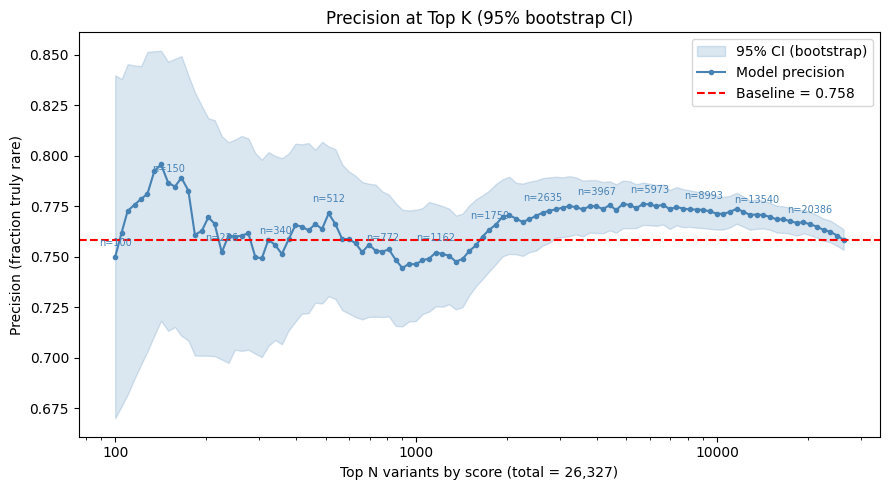

In [43]:

precision_at_top_k(df_test, best_model, start_point=100,)

In [4]:
# use AF < 0.01 as rare variant definition as some paper suggested: https://www.nature.com/articles/ng.1074, https://www.nature.com/articles/s41586-021-03855-y

best_model_with = joblib.load("results_logistic/model/best_model_VS_track_strand_with-.pkl")
df_train_with = pd.read_parquet("results_logistic/model/df_train_VS_track_strand_with-.parquet")



In [5]:
from sklearn.model_selection import train_test_split

_, df_test_with = train_test_split(
    df_train_with,
    test_size=0.2,
    random_state=42,
    stratify=df_train_with["rare"]
)


/opt/modules/i12g/anaconda/envs/IDPproject_indel_26/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
Bootstrapping: 100%|██████████| 1000/1000 [00:01<00:00, 508.44it/s]


     top_%  n_variants  precision  baseline_precision  precision_low  precision_high
  0.003798         100   0.790000            0.758461       0.710000        0.870000
  0.399014         105   0.790476            0.758461       0.704762        0.866667
  0.419954         110   0.781818            0.758461       0.709091        0.854545
  0.441992         116   0.775862            0.758461       0.698276        0.853448
  0.465187         122   0.786885            0.758461       0.704918        0.852459
  0.489599         128   0.781250            0.758461       0.710938        0.851562
  0.515292         135   0.785185            0.758461       0.711111        0.844630
  0.542334         142   0.781690            0.758461       0.718310        0.845070
  0.570794         150   0.786667            0.758461       0.720000        0.853333
  0.600749         158   0.791139            0.758461       0.727848        0.848101
  0.632275         166   0.795181            0.758461       0.728

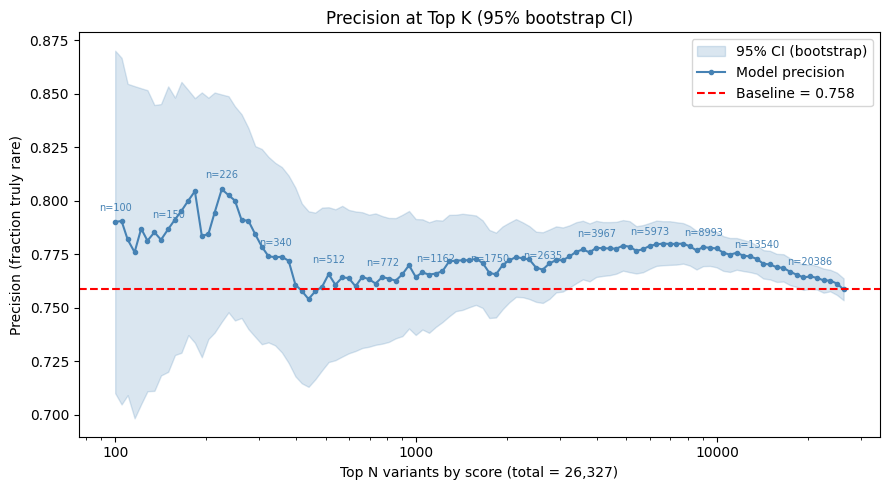

In [6]:

precision_at_top_k(df_test_with, best_model_with, start_point=100,)

/opt/modules/i12g/anaconda/envs/IDPproject_indel_26/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
Screening tracks: 100%|██████████| 793/793 [00:00<00:00, 1526.21it/s]
/scratch/tmp/zhow/ipykernel_2275727/4040965075.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", top_n_tracks)


Top tracks by precision at top 10%:
  CL:0000625 polyA plus RNA-seq_._ref: 0.783
  CL:0000624 polyA plus RNA-seq_._ref: 0.782
  CL:0000624 polyA plus RNA-seq_._alt: 0.782
  CL:0000625 polyA plus RNA-seq_._alt: 0.782
  CL:0002319 polyA plus RNA-seq_+_ref: 0.781
  UBERON:0000473 gtex Testis polyA plus RNA-seq_._ref: 0.781
  EFO:0003072 polyA plus RNA-seq_._alt: 0.780
  EFO:0003072 polyA plus RNA-seq_._ref: 0.780
  CL:0002319 polyA plus RNA-seq_+_alt: 0.780
  UBERON:0000473 gtex Testis polyA plus RNA-seq_._alt: 0.780


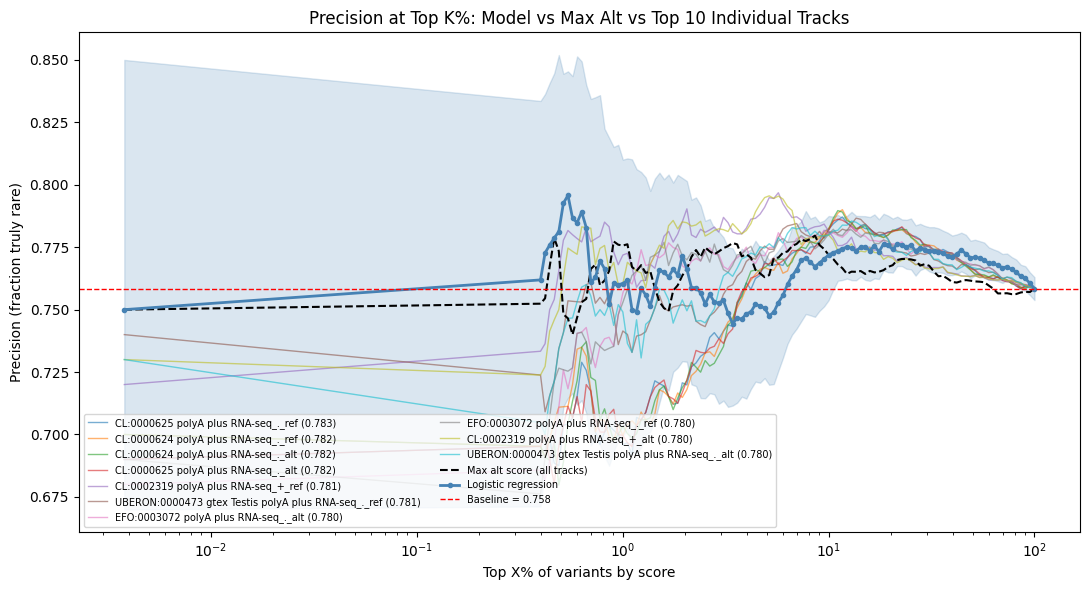

In [45]:
precision_at_top_k_per_track(df_test, best_model, n_bootstrap=100, top_n_tracks=10)

In [34]:
df_train.head

<bound method NDFrame.head of                                variant_id  rare  index  \
0                  chr4:48753750:CTTTAT>C     0     55   
1                 chr15:29543148:TACATG>T     0     64   
2                  chr4:94941618:TAAAAG>T     1     39   
3                  chr8:18558823:AAAAAC>A     1      4   
4                 chr15:53608470:ACAGGT>A     0     33   
...                                   ...   ...    ...   
131629      chr5:154228595:TAACAAATTCTC>T     1      6   
131630      chr4:172390176:ATTGTTTAATAT>A     1     89   
131631           chr2:48040396:G>GGTTGTGA     1     14   
131632  chr3:132285588:C>CGCCCAGCACTTCCCT     1    114   
131633       chr5:59384357:GGCCAATCAGCA>G     1     43   

        CL:0000047 polyA plus RNA-seq_+_alt  CL:0000062 total RNA-seq_+_alt  \
0                                       NaN                             NaN   
1                                       NaN                             NaN   
2                                 -0

/opt/modules/i12g/anaconda/envs/IDPproject_indel_26/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
Screening tracks: 100%|██████████| 793/793 [00:05<00:00, 146.22it/s]


Top tracks by precision at top 10%:
  UBERON:0000992 polyA plus RNA-seq_._alt: 0.779
  CL:0001059 polyA plus RNA-seq_._alt: 0.778
  UBERON:0000992 polyA plus RNA-seq_._ref: 0.778
  CL:0001059 polyA plus RNA-seq_._ref: 0.777
  CL:0002319 polyA plus RNA-seq_+_alt: 0.777
  CL:0002319 polyA plus RNA-seq_+_ref: 0.777
  CL:0000624 polyA plus RNA-seq_._ref: 0.776
  UBERON:0000473 gtex Testis polyA plus RNA-seq_._ref: 0.776
  UBERON:0000473 gtex Testis polyA plus RNA-seq_._alt: 0.776
  UBERON:0002370 polyA plus RNA-seq_._ref: 0.776


/scratch/tmp/zhow/ipykernel_627272/493351088.py:75: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", top_n_tracks)
/scratch/tmp/zhow/ipykernel_627272/493351088.py:35: RuntimeWarning: invalid value encountered in log10
  if x > 0 and np.log10(x) - np.log10(last_x + 1e-10) > label_spacing:


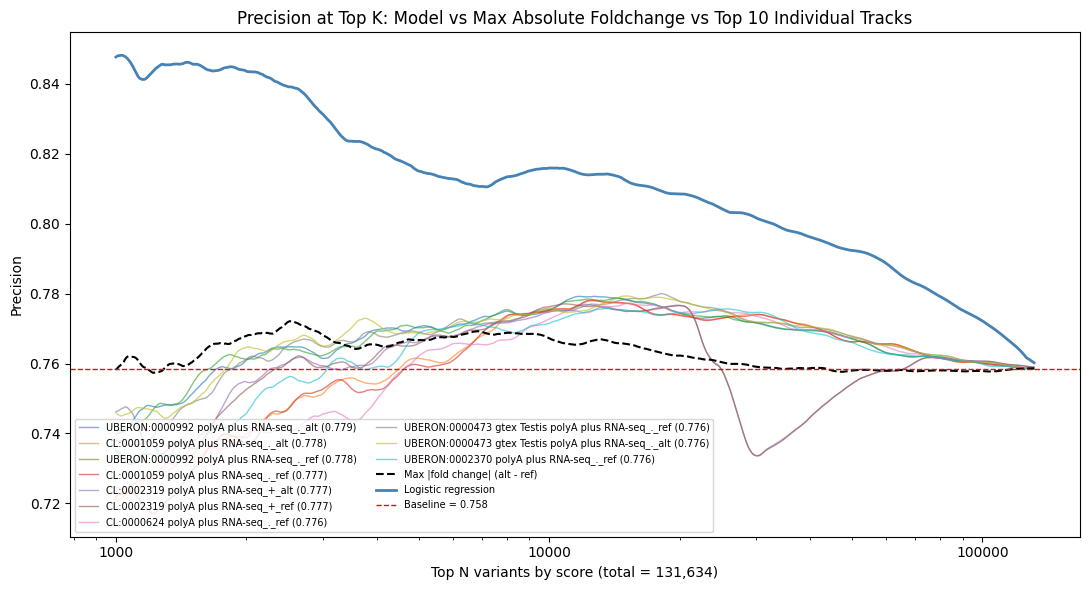

In [38]:
precision_at_top_k_per_track_smooth(df_train, best_model, smooth_window=15, top_n_tracks=10, show_max_alt=True)

In [47]:

best_model_expr = joblib.load("results_logistic/model/best_model_VS_track_strand_expr_log10median.pkl")
df_train_expr = pd.read_parquet("results_logistic/model/df_train_VS_track_strand_expr_log10median.parquet")


In [6]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import train_test_split
import pandas as pd
import joblib
from sklearn.metrics import roc_auc_score
import glob

In [50]:
files = sorted(glob.glob("results_logistic/batch_features/batch_*.parquet"))[:4]
all_gene_features_merged = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)

df_allele = pd.read_parquet("/s/project/benchmark-lm/selection_inference/benchmarklm/sample_variants/data/gnomad_v4_observed_indels_5_to_20_length_vep_scored_downsampled.parquet")
df_allele["variant_id"] = (
    df_allele["Chromosome"].astype(str)
    + ":"
    + df_allele["pos"].astype(str)
    + ":"
    + df_allele["ref"].astype(str)
    + ">"
    + df_allele["alt"].astype(str)
)

df_allele["rare"] = (
    df_allele["AF"] < 0.01
).astype(int) 

df_train = df_allele[["variant_id", "rare"]].merge(
    all_gene_features_merged,
    on="variant_id",
    how="inner"
)

del df_allele

In [51]:
df_sampled = df_train.sample(frac=0.1, random_state=42)
df_rest = df_train.drop(df_sampled.index)

In [61]:
precision_at_top_k_per_track(df_rest, best_model_expr)

: 

/opt/modules/i12g/anaconda/envs/IDPproject_indel_26/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
Bootstrapping: 100%|██████████| 1000/1000 [00:01<00:00, 549.72it/s]


     top_%  n_variants  precision  baseline_precision  precision_low  precision_high
  0.004305         100   0.810000            0.761011       0.729750        0.880000
  0.449217         104   0.817308            0.761011       0.730769        0.875000
  0.472493         109   0.807339            0.761011       0.724771        0.871560
  0.496976         115   0.800000            0.761011       0.730435        0.869565
  0.522727         121   0.801653            0.761011       0.727273        0.867769
  0.549813         127   0.795276            0.761011       0.732283        0.866142
  0.578301         134   0.805970            0.761011       0.738806        0.865672
  0.608267         141   0.815603            0.761011       0.744681        0.865426
  0.639784         148   0.810811            0.761011       0.743243        0.871622
  0.672935         156   0.814103            0.761011       0.737179        0.865385
  0.707804         164   0.798780            0.761011       0.731

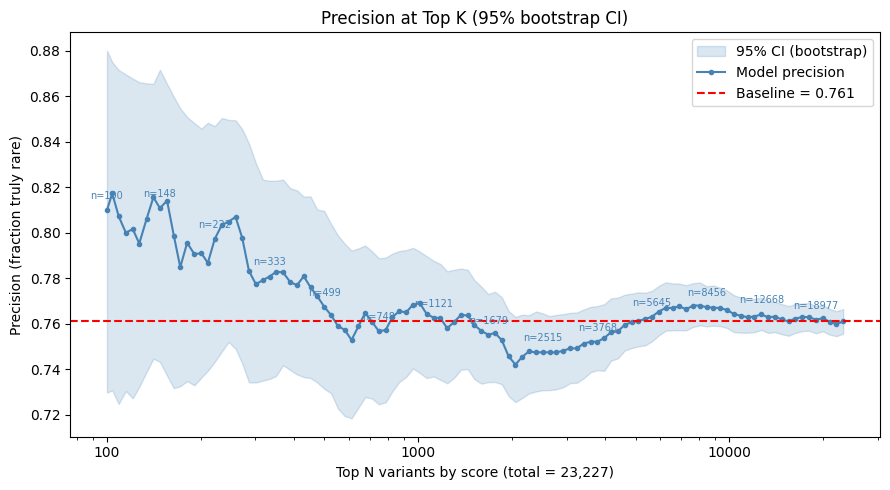

In [52]:
precision_at_top_k(df_rest, best_model_expr, start_point=100)

## Delta

In [11]:

best_model_delta_with = joblib.load("results_logistic/model/best_model_VS_track_strand_delta_with-.pkl")
df_train_delta_with = pd.read_parquet("results_logistic/model/df_train_VS_track_strand_delta_with-.parquet")

best_model_delta = joblib.load("results_logistic_NaNmean/best_model_VS_track_strand_delta.pkl")
df_train_delta = pd.read_parquet("results_logistic_NaNmean/df_train_VS_track_strand_delta.parquet")


In [19]:
from sklearn.model_selection import train_test_split

_, df_test_delta_with = train_test_split(
    df_train_delta_with,
    test_size=0.2,
    random_state=42,
    stratify=df_train_delta_with["rare"]
)

from sklearn.model_selection import train_test_split

_, df_test_delta = train_test_split(
    df_train_delta,
    test_size=0.2,
    random_state=42,
    stratify=df_train_delta["rare"]
)


/opt/modules/i12g/anaconda/envs/IDPproject_indel_26/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
Screening tracks: 100%|██████████| 372/372 [00:00<00:00, 1634.56it/s]
/scratch/tmp/zhow/ipykernel_2280361/4040965075.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", top_n_tracks)


Top tracks by precision at top 10%:
  CL:0000897 polyA plus RNA-seq_medians: 0.794
  CL:0000895 polyA plus RNA-seq_medians: 0.793
  CL:0000900 polyA plus RNA-seq_medians: 0.793
  CL:0000792 polyA plus RNA-seq_medians: 0.791
  CL:0000909 polyA plus RNA-seq_medians: 0.791
  CL:0000623 total RNA-seq_medians: 0.790
  CL:0000900 total RNA-seq_medians: 0.790
  CL:0001053 polyA plus RNA-seq_medians: 0.789
  CL:0000823 polyA plus RNA-seq_medians: 0.789
  UBERON:0002168 total RNA-seq_medians: 0.788


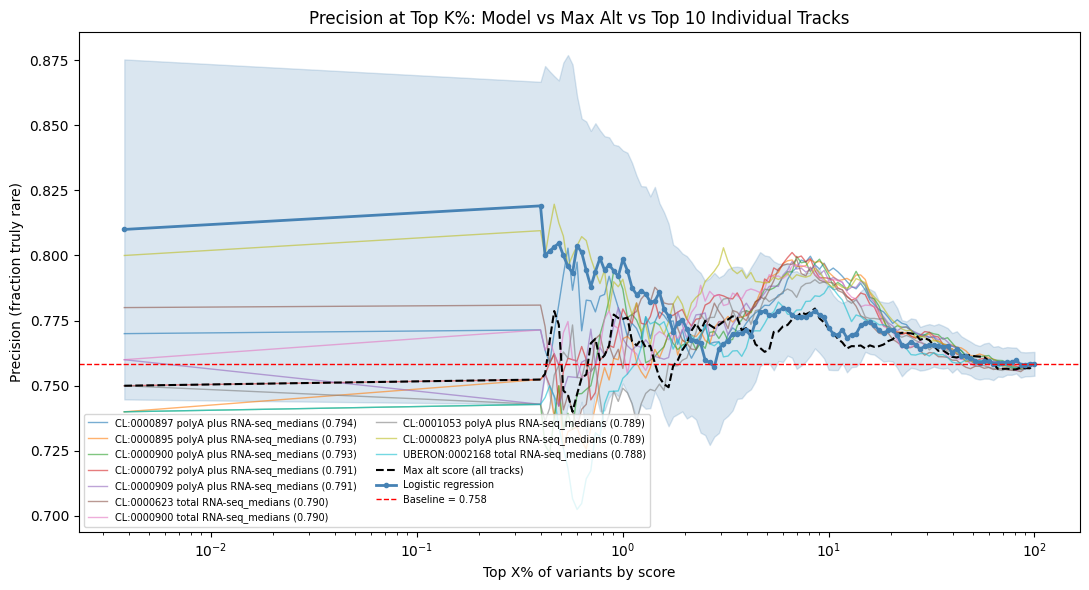

In [20]:
precision_at_top_k_per_track(df_test_delta_with, best_model_delta_with)

/opt/modules/i12g/anaconda/envs/IDPproject_indel_26/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
Bootstrapping: 100%|██████████| 1000/1000 [00:01<00:00, 511.29it/s]


     top_%  n_variants  precision  baseline_precision  precision_low  precision_high
  0.003798         100   0.810000            0.758461       0.730000        0.890000
  0.399014         105   0.819048            0.758461       0.723810        0.885714
  0.419954         110   0.800000            0.758461       0.718182        0.872727
  0.441992         116   0.801724            0.758461       0.724138        0.879310
  0.465187         122   0.803279            0.758461       0.729303        0.868852
  0.489599         128   0.804688            0.758461       0.726562        0.867188
  0.515292         135   0.800000            0.758461       0.725926        0.866852
  0.542334         142   0.795775            0.758461       0.732394        0.866197
  0.570794         150   0.793333            0.758461       0.733333        0.866667
  0.600749         158   0.803797            0.758461       0.734177        0.860759
  0.632275         166   0.801205            0.758461       0.734

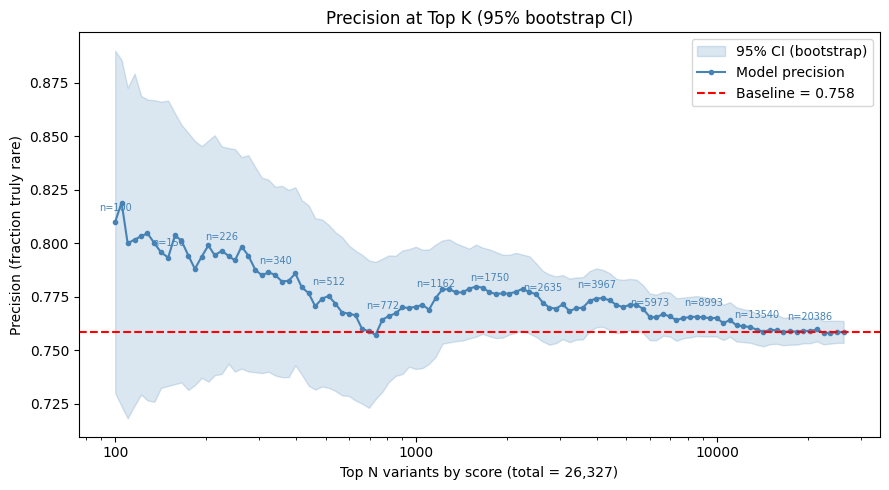

In [21]:
precision_at_top_k(df_test_delta_with, best_model_delta_with, start_point=100)

/opt/modules/i12g/anaconda/envs/IDPproject_indel_26/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
Bootstrapping: 100%|██████████| 1000/1000 [00:01<00:00, 511.61it/s]


     top_%  n_variants  precision  baseline_precision  precision_low  precision_high
  0.003798         100   0.830000            0.758461       0.760000        0.920000
  0.399014         105   0.828571            0.758461       0.761905        0.914286
  0.419954         110   0.836364            0.758461       0.763636        0.900000
  0.441992         116   0.836207            0.758461       0.758621        0.896552
  0.465187         122   0.836066            0.758461       0.762090        0.893443
  0.489599         128   0.828125            0.758461       0.750000        0.890625
  0.515292         135   0.814815            0.758461       0.755556        0.888889
  0.542334         142   0.823944            0.758461       0.746479        0.880282
  0.570794         150   0.813333            0.758461       0.753333        0.873333
  0.600749         158   0.810127            0.758461       0.753165        0.873418
  0.632275         166   0.813253            0.758461       0.752

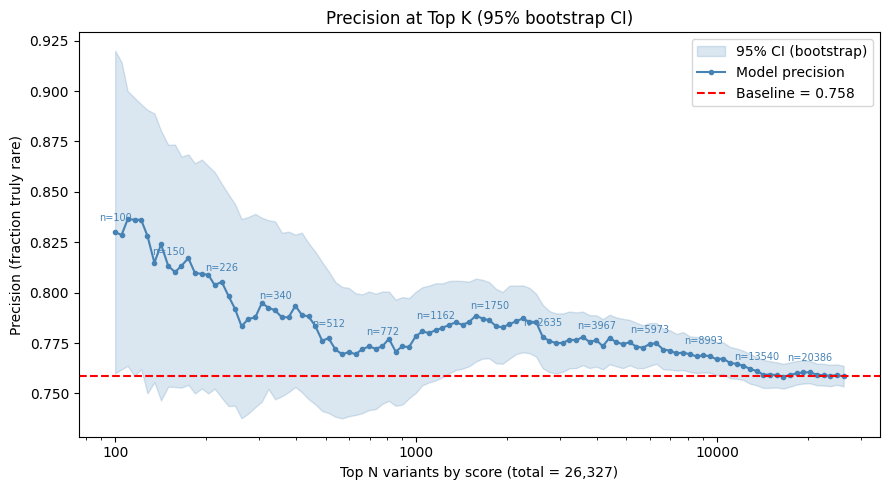

In [22]:
precision_at_top_k(df_test_delta, best_model_delta, start_point=100)

In [14]:
from sklearn.model_selection import train_test_split

_, df_test_delta = train_test_split(
    df_train_delta_with,
    test_size=0.2,
    random_state=42,
    stratify=df_train_delta_with["rare"]
)


/opt/modules/i12g/anaconda/envs/IDPproject_indel_26/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
Bootstrapping: 100%|██████████| 1000/1000 [00:01<00:00, 522.89it/s]


     top_%  n_variants  precision  baseline_precision  precision_low  precision_high
  0.003798         100   0.850000            0.758461       0.760000        0.910000
  0.399014         105   0.838095            0.758461       0.761905        0.905000
  0.419954         110   0.836364            0.758461       0.754545        0.900000
  0.441992         116   0.818966            0.758461       0.741379        0.896552
  0.465187         122   0.827869            0.758461       0.737705        0.885451
  0.489599         128   0.812500            0.758461       0.734375        0.882812
  0.515292         135   0.807407            0.758461       0.733333        0.874074
  0.542334         142   0.809859            0.758461       0.725352        0.873239
  0.570794         150   0.786667            0.758461       0.719833        0.860000
  0.600749         158   0.784810            0.758461       0.721519        0.854430
  0.632275         166   0.783133            0.758461       0.722

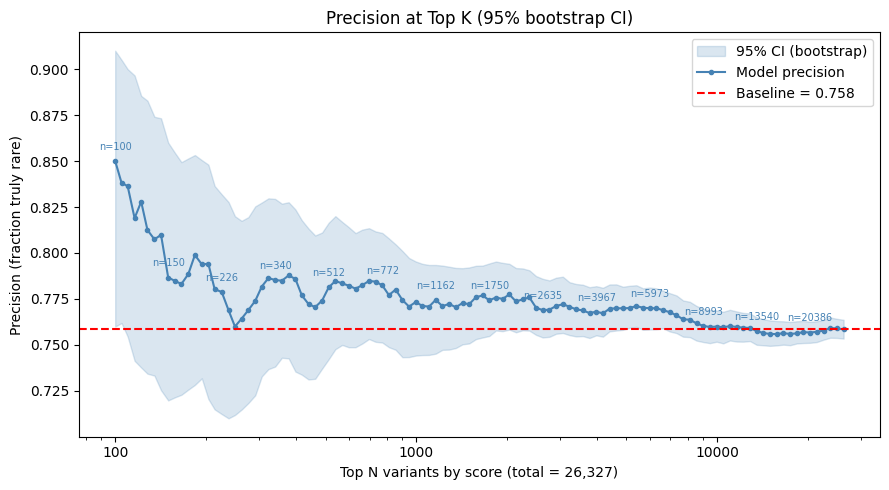

In [15]:
precision_at_top_k(df_test_delta, best_model_delta, start_point=100)

/opt/modules/i12g/anaconda/envs/IDPproject_indel_26/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
Bootstrapping: 100%|██████████| 1000/1000 [00:00<00:00, 1144.82it/s]


     top_%  n_variants  precision  baseline_precision  precision_low  precision_high
  0.038745         100   0.950000            0.749709       0.900000        0.980000
  3.927694         101   0.950495            0.749709       0.900990        0.980198
  4.085849         105   0.952381            0.749709       0.904762        0.980952
  4.250372         109   0.954128            0.749709       0.908257        0.981651
  4.421520         114   0.956140            0.749709       0.912061        0.982456
  4.599560         118   0.957627            0.749709       0.906780        0.983051
  4.784768         123   0.951220            0.749709       0.910569        0.983740
  4.977435         128   0.953125            0.749709       0.914062        0.984375
  5.177859         133   0.954887            0.749709       0.909774        0.984962
  5.386354         139   0.949640            0.749709       0.906475        0.985612
  5.603245         144   0.951389            0.749709       0.902

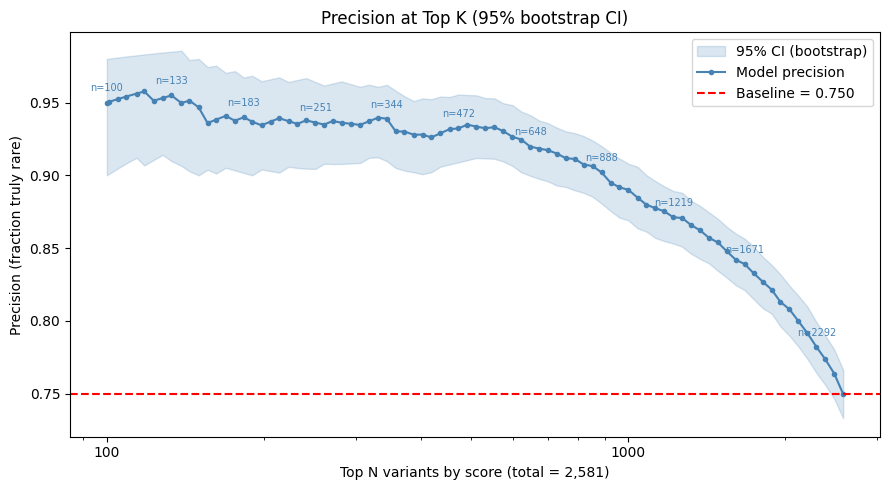

In [ ]:
#precision_at_top_k(df_rest, best_model_expr, start_point=100)
# with 0.08 overfitted data --> acceptable?

/opt/modules/i12g/anaconda/envs/IDPproject_indel_26/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
Screening tracks: 100%|██████████| 92304/92304 [00:14<00:00, 6308.24it/s]
/scratch/tmp/zhow/ipykernel_630989/493351088.py:25: RuntimeWarning: Mean of empty slice
  {"top_%": pct * 100, "n_variants": k, "precision": y[sorted_idx[:k]].mean()}
/opt/modules/i12g/anaconda/envs/IDPproject_indel_26/lib/python3.11/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/scratch/tmp/zhow/ipykernel_630989/493351088.py:75: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", top_n_tracks)


Top tracks by precision at top 10%:
  Fukomys_damarensis_UBERON:0018116 polyA plus RNA-seq_-: 0.791
  Cercopithecus_mona_UBERON:0002168 polyA plus RNA-seq_-: 0.790
  Orcinus_orca_UBERON:0005270 polyA plus RNA-seq_+: 0.790
  Camelus_dromedarius_UBERON:0009834 gtex Brain_Frontal_Cortex_BA9 polyA plus RNA-seq_-: 0.789
  Cercopithecus_mona_UBERON:0018117 polyA plus RNA-seq_-: 0.789
  Hoolock_leuconedys_UBERON:0018115 polyA plus RNA-seq_-: 0.789
  Orcinus_orca_UBERON:0018116 polyA plus RNA-seq_+: 0.789
  Pan_paniscus_UBERON:0001224 polyA plus RNA-seq_-: 0.789
  Camelus_dromedarius_UBERON:0002079 total RNA-seq_-: 0.788
  Camelus_dromedarius_UBERON:0002080 total RNA-seq_-: 0.788


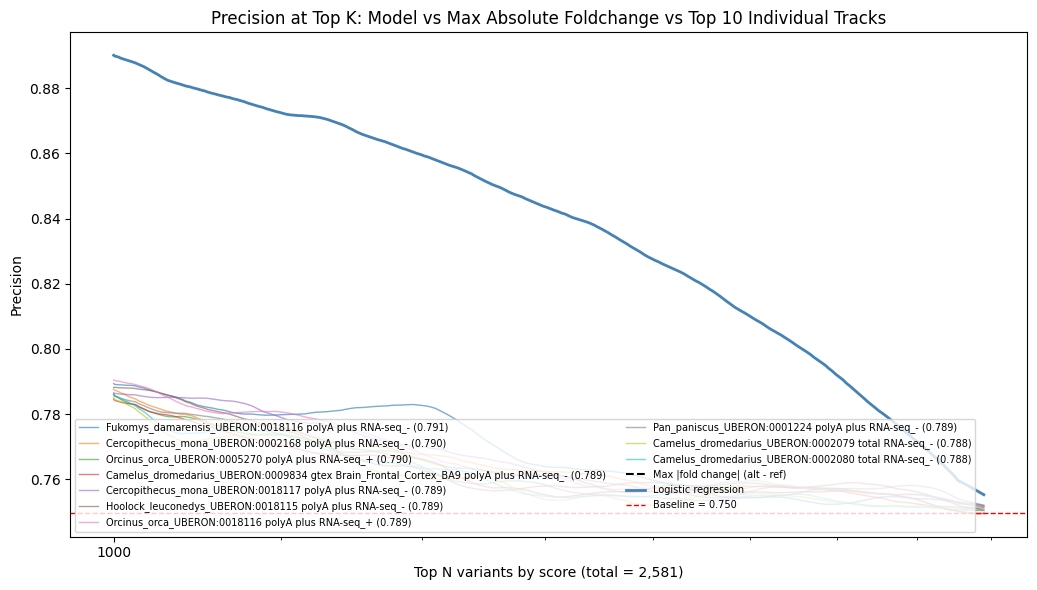

In [ ]:
precision_at_top_k_per_track_smooth(df_train_expr, best_model_expr, starting_point=100, smooth_window=15, top_n_tracks=10, show_max_alt=True)

## Debugging!!


In [74]:
# Test with just CADD scores as a baseline
df_cadd = df_allele[["variant_id", "CADD_PHRED", "CADD_RAW", "rare"]].dropna()
X_cadd = df_cadd[["CADD_PHRED", "CADD_RAW"]].values
y_cadd = df_cadd["rare"].values

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
model_cadd = LogisticRegression(class_weight="balanced", random_state=42)
scores = cross_val_score(model_cadd, X_cadd, y_cadd, cv=5, scoring="roc_auc")
print(f"CADD only AUC: {scores.mean():.3f}")

CADD only AUC: 0.548


In [78]:
# What is the AF distribution of your indels?
print(df_allele["AF"].describe())

# How are indels distributed by size?
df_allele["indel_size"] = df_allele["variant_id"].apply(
    lambda x: len(x.split(">")[1]) - len(x.split(">")[0].split(":")[-1])
)
print(df_allele["indel_size"].describe())
print(df_allele.groupby("rare")["indel_size"].describe())

count    461906.000000
mean          0.036170
std           0.121078
min           0.000007
25%           0.000007
50%           0.001000
75%           0.008417
max           1.000000
Name: AF, dtype: float64
count    461906.000000
mean          0.686960
std          12.821725
min         -20.000000
25%         -12.000000
50%           5.000000
75%          12.000000
max          20.000000
Name: indel_size, dtype: float64
         count      mean        std   min   25%  50%   75%   max
rare                                                            
0     107880.0  2.185206  12.280423 -20.0 -10.0  7.0  12.0  20.0
1     354026.0  0.230410  12.947784 -20.0 -12.0  5.0  12.0  20.0


In [79]:
# Add indel size as a feature
df_allele["indel_size"] = df_allele["variant_id"].apply(
    lambda x: len(x.split(">")[1]) - len(x.split(">")[0].split(":")[-1])
)
df_allele["abs_indel_size"] = df_allele["indel_size"].abs()

# Quick test — does indel size alone predict rarity?
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import numpy as np

X_size = df_allele[["indel_size", "abs_indel_size"]].values
y_size = df_allele["rare"].values

scores = cross_val_score(
    LogisticRegression(class_weight="balanced"),
    X_size, y_size, cv=5, scoring="roc_auc"
)
print(f"Indel size only AUC: {scores.mean():.3f}")

Indel size only AUC: 0.243


indel_size
 8     0.664248
 6     0.664299
 12    0.680915
 10    0.681928
 5     0.710305
-8     0.720837
 16    0.738275
 14    0.741732
-12    0.753289
 15    0.756444
 20    0.772540
 9     0.772730
-6     0.772866
-16    0.773176
-10    0.779103
-20    0.786436
 11    0.788744
 18    0.789053
 13    0.797106
 7     0.801968
-14    0.806055
-18    0.807801
 17    0.817339
-15    0.824084
-5     0.828642
-19    0.834635
-9     0.837995
 19    0.838826
-7     0.839393
-17    0.846087
-11    0.847191
-13    0.851965
Name: rare, dtype: float64


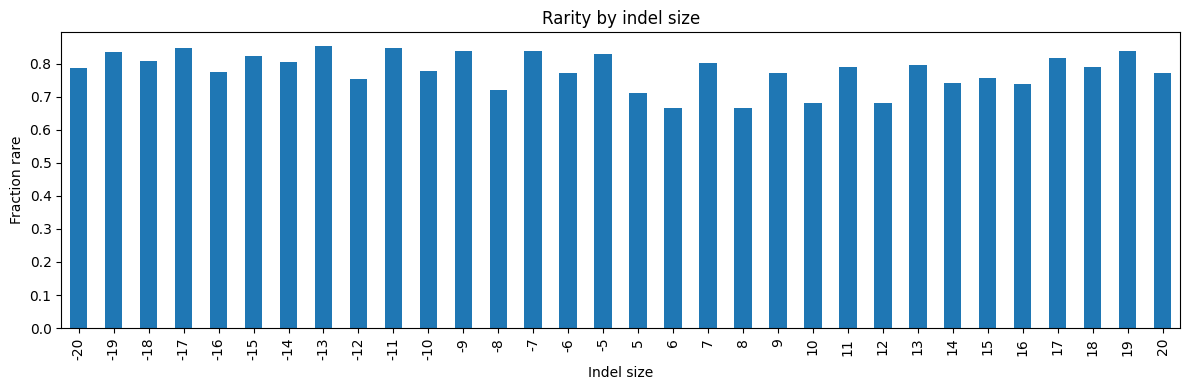

In [81]:
# Look at mean rarity by indel size
print(df_allele.groupby("indel_size")["rare"].mean().sort_values())

# And distribution
import matplotlib.pyplot as plt
df_allele.groupby("indel_size")["rare"].mean().plot(kind="bar", figsize=(12, 4))
plt.xlabel("Indel size")
plt.ylabel("Fraction rare")
plt.title("Rarity by indel size")
plt.tight_layout()
plt.show()

indel_size
-20    0.786436
-19    0.834635
-18    0.807801
-17    0.846087
-16    0.773176
-15    0.824084
-14    0.806055
-13    0.851965
-12    0.753289
-11    0.847191
-10    0.779103
-9     0.837995
-8     0.720837
-7     0.839393
-6     0.772866
-5     0.828642
 5     0.710305
 6     0.664299
 7     0.801968
 8     0.664248
 9     0.772730
 10    0.681928
 11    0.788744
 12    0.680915
 13    0.797106
 14    0.741732
 15    0.756444
 16    0.738275
 17    0.817339
 18    0.789053
 19    0.838826
 20    0.772540
Name: rare, dtype: float64


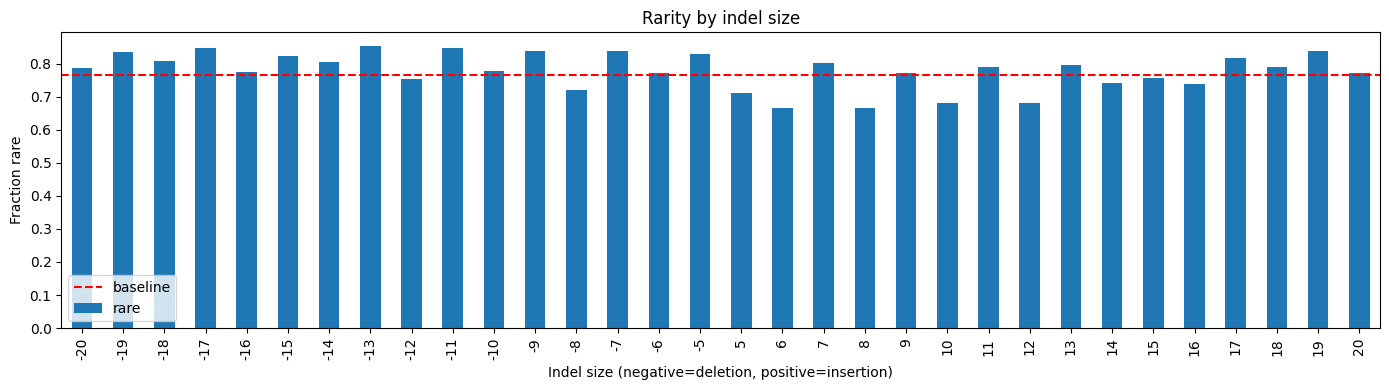

In [82]:
# Sort by indel size to see the full pattern clearly
pattern = df_allele.groupby("indel_size")["rare"].mean().sort_index()
print(pattern)

import matplotlib.pyplot as plt
pattern.plot(kind="bar", figsize=(14, 4))
plt.axhline(y=df_allele["rare"].mean(), color="red", linestyle="--", label="baseline")
plt.xlabel("Indel size (negative=deletion, positive=insertion)")
plt.ylabel("Fraction rare")
plt.title("Rarity by indel size")
plt.legend()
plt.tight_layout()
plt.savefig("results_logistic/rarity_by_indel_size.png", dpi=150)
plt.show()

In [84]:
print(df_allele.columns.tolist())

['Chromosome', 'pos', 'ref', 'alt', 'filter', 'AC', 'AN', 'AF', 'is_indel', 'len_ref', 'len_alt', 'is_insertion', 'is_deletion', 'indel_length', 'indel_type', 'var_id', 'Uploaded_variation', 'Location', 'Allele', 'Gene', 'Feature', 'Feature_type', 'Consequence', 'cDNA_position', 'CDS_position', 'Protein_position', 'Amino_acids', 'Codons', 'Existing_variation', 'IMPACT', 'DISTANCE', 'STRAND', 'FLAGS', 'SOURCE', 'CADD_PHRED', 'CADD_RAW', 'phastcons_470', 'phylop_470', 'phastcons_100', 'phylop_100', 'variant_id', 'rare', 'indel_size', 'abs_indel_size', 'neg_abs_indel_size']


In [88]:
def parse_conservation(series):
    """Take mean across all comma-separated conservation scores"""
    return series.astype(str).apply(
        lambda x: np.mean([float(v) for v in x.split(",") if v not in ["", "-", "nan"]])
        if x not in ["nan", "-", ""] else np.nan
    ).fillna(0)

# Test numeric features with proper parsing
numeric_features = {
    "CADD_PHRED": lambda s: pd.to_numeric(s, errors="coerce").fillna(0),
    "CADD_RAW": lambda s: pd.to_numeric(s, errors="coerce").fillna(0),
    "phastcons_470": parse_conservation,
    "phylop_470": parse_conservation,
    "phastcons_100": parse_conservation,
    "phylop_100": parse_conservation,
    "abs_indel_size": lambda s: pd.to_numeric(s, errors="coerce").fillna(0),
}

y_test = df_allele["rare"].values

for col, parser in numeric_features.items():
    if col not in df_allele.columns:
        continue
    X_test = parser(df_allele[col]).values.reshape(-1, 1)
    scores = cross_val_score(
        LogisticRegression(class_weight="balanced"),
        X_test, y_test, cv=5, scoring="roc_auc"
    )
    print(f"{col:25s} AUC: {scores.mean():.3f}")

CADD_PHRED                AUC: 0.554
CADD_RAW                  AUC: 0.554
phastcons_470             AUC: 0.499
phylop_470                AUC: 0.500
phastcons_100             AUC: 0.506
phylop_100                AUC: 0.505
abs_indel_size            AUC: 0.379
